In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

In [2]:
COLUMNS = {
    'DY-ADJ_AF-OPEN_PRICE_2': 'open',
    'DY-ADJ_AF-HIGHEST_PRICE_2': 'high',
    'DY-ADJ_AF-LOWEST_PRICE_2': 'low',
    'DY-ADJ_AF-CLOSE_PRICE_2': 'close',
    'DY-BASIC-MARKET_VALUE': 'market_cap',

    'LEVEL1_NAME': 'industry',
    'LEVEL2_NAME': 'sub_industry',
    'LEVEL3_NAME': 'sub_sub_industry',
}

In [3]:
def load_data(file_path: str, columns: list[str] = None, rename_map: dict[str, str] = COLUMNS) -> pd.DataFrame:
    """
    载入数据
    """
    df = pd.read_parquet(file_path, columns=columns)

    if file_path == 'industry.parquet':
        df = df.swaplevel('CODE', 'DATE')
        df = df.sort_index()
    elif file_path == 'st.parquet':
        df = df.notna().astype(bool)
        df = df.stack(future_stack=True).to_frame('st')
    elif file_path == '停牌.parquet':
        df = df.pivot(index='日期', columns='股票代码', values='是否停牌').fillna(0).astype(bool)
        df = df.stack().to_frame('suspended')

    df = df.reset_index()
    
    df.columns = ['date', 'ticker'] + list(df.columns[2:])

    df['date'] = pd.to_datetime(df['date'])

    df = df.set_index(['date', 'ticker'])
    df = df.sort_index()

    df = df.rename(columns=rename_map)
    return df

In [ ]:
def check_limits_and_ipo(df: pd.DataFrame, limit_pct=0.10, ipo_days=60) -> tuple[pd.DataFrame]:
    """
    检查涨跌停状态和IPO状态
    """
    df = df.sort_index()

    # 判断涨跌停
    prev_close = df.groupby(level='ticker')['close'].shift(1)

    limit_up = df['high'] >= prev_close * (1 + limit_pct)
    limit_down = df['low'] <= prev_close * (1 - limit_pct)

    # 判断IPO状态（假设第一个交易日为IPO日）
    first_trade_date = df.reset_index().groupby('ticker')['date'].transform('min')
    days_since_ipo = (df.reset_index()['date'] - first_trade_date).dt.days
    is_new = days_since_ipo < ipo_days

    # 重新对齐 index（避免 reset_index 带来的错位）
    is_new.index = df.index

    limit_up = limit_up.to_frame('limit_up')
    limit_down = limit_down.to_frame('limit_down')
    is_new = is_new.to_frame('is_new')

    return limit_up, limit_down, is_new

In [ ]:
def calculate_factor_and_returns(df_ohcl: pd.DataFrame, limit_up: pd.Series, limit_down: pd.Series, df_susp: pd.DataFrame, df_st: pd.DataFrame, is_new: pd.Series) -> pd.DataFrame:
    """
    计算因子值和未来收益率，并剔除不符合条件的股票
    """
    # 因子 =（t0日收盘/t-5日收盘）- 1
    df_ohcl['factor'] = df_ohcl['close'] / df_ohcl.groupby('ticker')['close'].shift(5) - 1

    # 收益率 =（t2日开盘/t1日开盘）- 1
    df_ohcl['return'] = df_ohcl.groupby('ticker')['open'].transform(lambda x: x.shift(-2) / x.shift(-1) - 1)

    # shift 到 t+1（交易时点）
    limit_up = limit_up.groupby(level='ticker').shift(-1)
    limit_down = limit_down.groupby(level='ticker').shift(-1)
    is_new = is_new.groupby(level='ticker').shift(-1)
    df_susp = df_susp.groupby(level='ticker').shift(-1)
    df_st = df_st.groupby(level='ticker').shift(-1)

    # 剔除涨跌停、停牌、ST、新股
    mask = (limit_up['limit_up'] | limit_down['limit_down'] | df_susp['suspended'] | df_st['st'] | is_new['is_new'])
    mask = mask.reindex(df_ohcl.index)

    df_ohcl = df_ohcl[~mask]

    # 剔除收益率为-100%的情况
    df_ohcl = df_ohcl[df_ohcl['return'] != -1]
    
    df_ohcl = df_ohcl.dropna()

    return df_ohcl

In [6]:
def standardize_raw(og_factors: pd.Series, n = 2.5) -> pd.Series:
    """
    因子载荷原始值标准化
    """
    # 计算中位数和MAD
    median = og_factors.median()
    mad = np.median(np.abs(og_factors - median))

    # 标准化
    factors = og_factors.clip(lower=median - n * mad, upper=median + n * mad)
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_rank(og_factors: pd.Series) -> pd.Series:
    """
    因子载荷排序值标准化
    """
    factors = og_factors.rank(method='average')
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_factor(df: pd.DataFrame) -> pd.DataFrame:
    """
    因子值标准化
    """
    df['factor_zscore_raw'] = df.groupby('date')['factor'].transform(standardize_raw)
    df['factor_rank_raw'] = df.groupby('date')['factor'].transform(standardize_rank)

    return df

In [7]:
def get_residual(x: pd.DataFrame, df_industry: pd.DataFrame, factor: str, industry_cols: list[str]) -> pd.Series:
    """
    获取因子值的残差
    """
    industry_dummies = pd.get_dummies(df_industry[industry_cols], drop_first=True)

    y = x[factor]

    X = pd.concat([x['log_market_cap'], industry_dummies], axis=1)
    X = sm.add_constant(X)

    model = sm.OLS(y, X.astype(float), missing='drop').fit()

    return model.resid

def neutralize_factors(df: pd.DataFrame, df_industry: pd.DataFrame, industry_cols: list[str] = ['industry']) -> pd.DataFrame:
    """
    因子值中性化
    """
    df = df.copy()

    df['log_market_cap'] = np.log(df['market_cap']) # 计算市值的对数

    df['factor_zscore_neu'] = df.groupby('date').apply(
                                    lambda x: get_residual(x, df_industry.loc[x.index], 'factor_zscore_raw', industry_cols)
                                ).reset_index(level=0, drop=True)

    df['factor_rank_neu'] = df.groupby('date').apply(
                                    lambda x: get_residual(x, df_industry.loc[x.index], 'factor_rank_raw', industry_cols)
                                ).reset_index(level=0, drop=True)
    
    df = df.drop(columns=df_industry.columns.tolist(), errors='ignore')
    return df

In [8]:
def calculate_ic_and_tstat(df: pd.DataFrame, factor_col: str) -> tuple[pd.Series, float]:
    """
    计算IC和t-stat
    """
    ic_series = df.groupby('date').apply(lambda x: stats.spearmanr(x[factor_col], x['return'])[0]).dropna()

    ic_mean, ic_stdev = ic_series.mean(), ic_series.std()

    ir = ic_mean / ic_stdev if ic_stdev != 0 else np.nan

    t_stat, p_val = stats.ttest_1samp(ic_series, 0)

    return ic_series, ic_mean, ic_stdev, ir, t_stat, p_val

In [9]:
def stratify(x: pd.Series, num_groups: int) -> pd.Series:
    """
    分层函数
    """
    return pd.qcut(x.rank(method='first'), q = num_groups, labels=False, duplicates='drop') + 1

def stratified_backtest(df: pd.DataFrame, factor_col: str, num_groups: int = 5, weight_method: str = 'equal', risk_free_rate: float = 0.03) -> tuple[pd.DataFrame, dict[pd.Series]]:
    """
    分层回测
    """
    df = df.copy()
    df['group'] = df.groupby('date')[factor_col].transform(lambda x: stratify(x, num_groups))

    if weight_method == 'equal':
        group_returns = df.groupby(['date', 'group'])['return'].mean().unstack()
    else:
        group_returns = df.groupby(['date', 'group']).apply(lambda x: np.average(x['return'], weights=x['market_cap'])).unstack()

    groups_performances, cum_returns = [], {}
    for group in range(1, num_groups + 1):
        annual_return = group_returns[group].mean() * 252

        annual_volatility = group_returns[group].std() * np.sqrt(252)

        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

        equity_curve = (1 + group_returns[group]).cumprod()

        max_drawdown = ((equity_curve.cummax() - equity_curve)/equity_curve.cummax()).max()

        groups_performances.append({
            'Group': group,
            'Annual Return': round(annual_return, 4),
            'Annual Volatility': round(annual_volatility, 4),
            'Sharpe Ratio': round(sharpe_ratio, 4),
            'Max Drawdown': round(max_drawdown, 4)
        })
        
        cum_returns[group] = equity_curve - 1

    return pd.DataFrame(groups_performances).set_index('Group'), cum_returns

In [10]:
def plot_results(ic_info: dict[str, dict[str]], backtest_results: dict[str, tuple[pd.DataFrame, dict[pd.Series]]], 
                 factors: list[str] = ['factor_zscore_raw','factor_zscore_neu', 'factor_rank_raw','factor_rank_neu']) -> None:
    """
    绘制结果图表
    """
    fig, axes = plt.subplots(len(factors), 4, figsize=(18, 5 * len(factors)))
    fig.suptitle('Factor Analysis Results', fontsize=14, y=1.01)

    for i, factor in enumerate(factors):
        group_stats, group_cum_rets = backtest_results[factor]
        ax_ic, ax_table, ax_cr, ax_gs = axes[i]

        # cumulative IC
        ic_series = ic_info[factor]['IC Series']
        cumulative_ic = ic_series.cumsum()
        ax_ic.plot(cumulative_ic.index, cumulative_ic.values, label='Cumulative IC')
        ax_ic.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax_ic.set_title(f'{factor} — cumulative IC')
        ax_ic.tick_params(axis='x', rotation=45)

        # IC stats table
        ax_table.axis('off')
        ic = ic_info[factor]
        table_data = [[k, f'{v:.5f}'] for k, v in ic.items() if k != 'IC Series']
        table = ax_table.table(cellText=table_data, colLabels=['Metric', 'Value'],
                               loc='center', cellLoc='left')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(0.6, 1.8)
        ax_table.set_title(f'{factor} — IC stats')

        # cumulative returns
        for group, curve in group_cum_rets.items():
            ax_cr.plot(curve.index, curve.values, label=f'Group {group}')
        ax_cr.set_title(f'{factor} — cumulative returns')
        ax_cr.legend(fontsize=8)
        ax_cr.set_xlabel('')
        ax_cr.tick_params(axis='x', rotation=45)

        # group stats bar chart
        stats = group_stats[factor] if isinstance(group_stats, dict) else group_stats
        x = np.arange(len(stats))
        width = 0.2
        for j, col in enumerate(stats.columns):
            ax_gs.bar(x + j * width, stats[col].values, width=width, label=col)
        ax_gs.set_xticks(x + width * (len(stats.columns) - 1) / 2)
        ax_gs.set_xticklabels([f'G{g}' for g in stats.index])
        ax_gs.axhline(0, color='black', linewidth=0.5)
        ax_gs.legend(fontsize=7)
        ax_gs.set_title(f'{factor} — group stats')

    plt.tight_layout()
    plt.show()

In [11]:
def optimize_portfolio(df_ohcl: pd.DataFrame, df_industry: pd.DataFrame, date: str, factor: str, n: int, industry: list[str], 
                        penalty: float, w_range: tuple[float, float], industry_range: tuple[float, float]) -> pd.Series:
    """
    优化投资组合
    """
    cross_section = df_ohcl.loc[date].copy() # 获取指定日期的截面数据
    df_ind = df_industry.loc[date] # 获取指定日期的行业数据

    # 选择因子值最小的100只股票
    mini_100 = cross_section.nsmallest(n, factor).copy()
    df_ind = df_ind.loc[mini_100.index] # 获取对应的行业数据

    exp_ret = mini_100[factor].values # 因子值作为预期收益率

    w = cp.Variable(len(mini_100)) # 权重变量
    Sigma = np.eye(len(mini_100)) # 协方差矩阵（假设为单位矩阵）

    objective = cp.Maximize(exp_ret @ w - penalty * cp.quad_form(w, Sigma)) # 目标函数
    constraints = [cp.sum(w) == 1, w >= w_range[0], w <= w_range[1]] # 权重约束

    industries = pd.get_dummies(df_ind[industry])
    industry_matrix = industries.values
    constraints.append(industry_matrix.T @ w >= industry_range[0])
    constraints.append(industry_matrix.T @ w <= industry_range[1])
    
    problem = cp.Problem(objective, constraints)
    problem.solve()

    return pd.Series(np.clip(w.value, w_range[0], w_range[1]), index=mini_100.index) if w.value is not None else pd.Series(1 / len(mini_100), index=mini_100.index)

def build_portfolio(df_ohcl: pd.DataFrame, df_industry: pd.DataFrame, factor: str = 'factor_rank_neu', n: int = 100, industry: list[str] = ['industry'], 
                       penalty: float = 0.05, w_range: tuple[float, float] = (0, 0.1), industry_range: tuple[float, float] = (0, 0.05)) -> pd.Series:
    """
    构建投资组合
    """
    results = {}
    for date in df_ohcl.index.get_level_values('date').unique():
        weights = optimize_portfolio(df_ohcl, df_industry, date, factor, n, industry, penalty, w_range, industry_range)
        results[date] = weights
    
    portfolio = pd.concat(results, axis=1).T
    
    # stack to (date, ticker) MultiIndex, drop NaN (unselected stocks)
    portfolio = portfolio.stack().to_frame('weight').dropna()
    portfolio.index.names = ['date', 'ticker']
    
    return portfolio

In [12]:
def backtest_portfolio(portfolio: pd.DataFrame, df_ohcl: pd.DataFrame, risk_free_rate: float = 0.03) -> pd.Series:
    """
    回测投资组合
    """
    merged = portfolio.join(df_ohcl['return'], how='inner')
    merged['weighted_return'] = merged['weight'] * merged['return']

    daily_returns = merged.groupby('date')['weighted_return'].sum()
    equity_curve = (1 + daily_returns).cumprod()

    metrics = {
        'Annual Return': daily_returns.mean() * 252,
        'Annual Volatility': daily_returns.std() * np.sqrt(252),
        'Sharpe Ratio': (daily_returns.mean() * 252 - risk_free_rate) / (daily_returns.std() * np.sqrt(252)) if daily_returns.std() != 0 else np.nan,
        'Max Drawdown': ((equity_curve.cummax() - equity_curve)/equity_curve.cummax()).max()
    } 

    return equity_curve, metrics

In [13]:
def plot_portfolio_performance(equity_curve: pd.Series, metrics: dict) -> None:
    """
    绘制投资组合表现图表
    """
    plt.figure(figsize=(10, 6))
    plt.plot(equity_curve.index, equity_curve.values, label='Portfolio Equity Curve')
    plt.title('Optimized Portfolio Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid()
    plt.legend()
    
    # 显示性能指标
    textstr = '\n'.join([f'{k}: {v:.4f}' for k, v in metrics.items()])
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)
    
    plt.show()

In [14]:
daily_data = load_data('daily_data.parquet', ['DATE', 'CODE', 'DY-ADJ_AF-OPEN_PRICE_2', 'DY-ADJ_AF-HIGHEST_PRICE_2',
                                                    'DY-ADJ_AF-LOWEST_PRICE_2', 'DY-ADJ_AF-CLOSE_PRICE_2',
                                                    'DY-BASIC-MARKET_VALUE'])
industry_data = load_data('industry.parquet', ['CODE', 'LEVEL1_NAME', 'LEVEL2_NAME', 'LEVEL3_NAME'])
st_data = load_data('st.parquet')
tp_data = load_data('停牌.parquet')

limit_up, limit_down, is_new = check_limits_and_ipo(daily_data)

In [15]:
df = calculate_factor_and_returns(daily_data, limit_up, limit_down, tp_data, st_data, is_new)

In [16]:
df = standardize_factor(df)

In [17]:
df = neutralize_factors(df, industry_data)

In [18]:
df

open     high      low    close    market_cap    factor  \
date       ticker                                                               
2010-03-04 000001  962.200  974.990  948.996  953.122  7.173552e+10  0.042889   
           000002  969.816  981.976  948.534  951.575  1.032450e+11 -0.009493   
           000005   62.887   63.083   59.448   59.939  5.577435e+09  0.079651   
           000006  211.260  220.480  207.451  208.454  5.274706e+09  0.028686   
           000009   52.085   54.451   50.596   50.727  1.263089e+10  0.034844   
...                    ...      ...      ...      ...           ...       ...   
2021-12-29 688799   39.600   41.220   39.600   40.030  3.754814e+09  0.042991   
           688800  145.190  152.000  137.000  150.200  1.622160e+10  0.086831   
           688819   43.227   43.309   42.832   42.953  4.114899e+10 -0.014907   
           688981   53.130   53.150   52.620   52.730  4.167637e+11 -0.005470   
           689009   68.500   69.680   66.640   67.580  4.762288e+10  0.008055   

                     return  factor_zscore_raw  factor_rank_raw  \
date       ticker                                                 
2010-03-04 000001  0.009524           1.666476         1.412729   
           000002 -0.002132           0.107800         0.280211   
           000005  0.128350           1.666476         1.594866   
           000006  0.007702           1.505923         1.293639   
           000009  0.008649           1.666476         1.373032   
...                     ...                ...              ...   
2021-12-29 688799  0.003008           1.601654         1.378200   
           688800 -0.003701           1.718081         1.604698   
           688819  0.000464          -0.008656         0.019215   
           688981  0.002844           0.253829         0.392078   
           689009  0.014855           0.629983         0.800100   

                   log_market_cap  factor_zscore_neu  factor_rank_neu  
date       ticker                                                      
2010-03-04 000001       24.996252           1.732509         1.438699  
           000002       25.360371           0.252644         0.447948  
           000005       22.441995           1.550618         1.492411  
           000006       22.386189           1.385079         1.186018  
           000009       23.259411           1.623638         1.346256  
...                           ...                ...              ...  
2021-12-29 688799       22.046305           1.026747         0.814395  
           688800       23.509610           1.857243         1.744309  
           688819       24.440465           0.244690         0.267620  
           688981       26.755785           0.018800         0.149328  
           689009       24.586579           0.589069         0.774464  

[7663291 rows x 12 columns]

In [19]:
ic_info = {}
for col in ['factor_zscore_raw', 'factor_rank_raw', 'factor_zscore_neu', 'factor_rank_neu']:
    ic_series, ic_mean, ic_stdev, ir, t_stat, p_val = calculate_ic_and_tstat(df, col)
    ic_info[col] = {
        'IC Series': ic_series,
        'IC Mean': round(float(ic_mean), 5),
        'IC Std': round(float(ic_stdev), 5),
        'IR': round(float(ir), 5),
        't-stat': round(float(t_stat), 5),
        'p-value': round(float(p_val), 5)
    }

In [20]:
backtest_results = {}
for col in ['factor_zscore_raw', 'factor_rank_raw', 'factor_zscore_neu', 'factor_rank_neu']:
    group_performances, cumulative_returns = stratified_backtest(df, col, num_groups=5, weight_method='equal', risk_free_rate=0.03)
    backtest_results[col] = (group_performances, cumulative_returns)

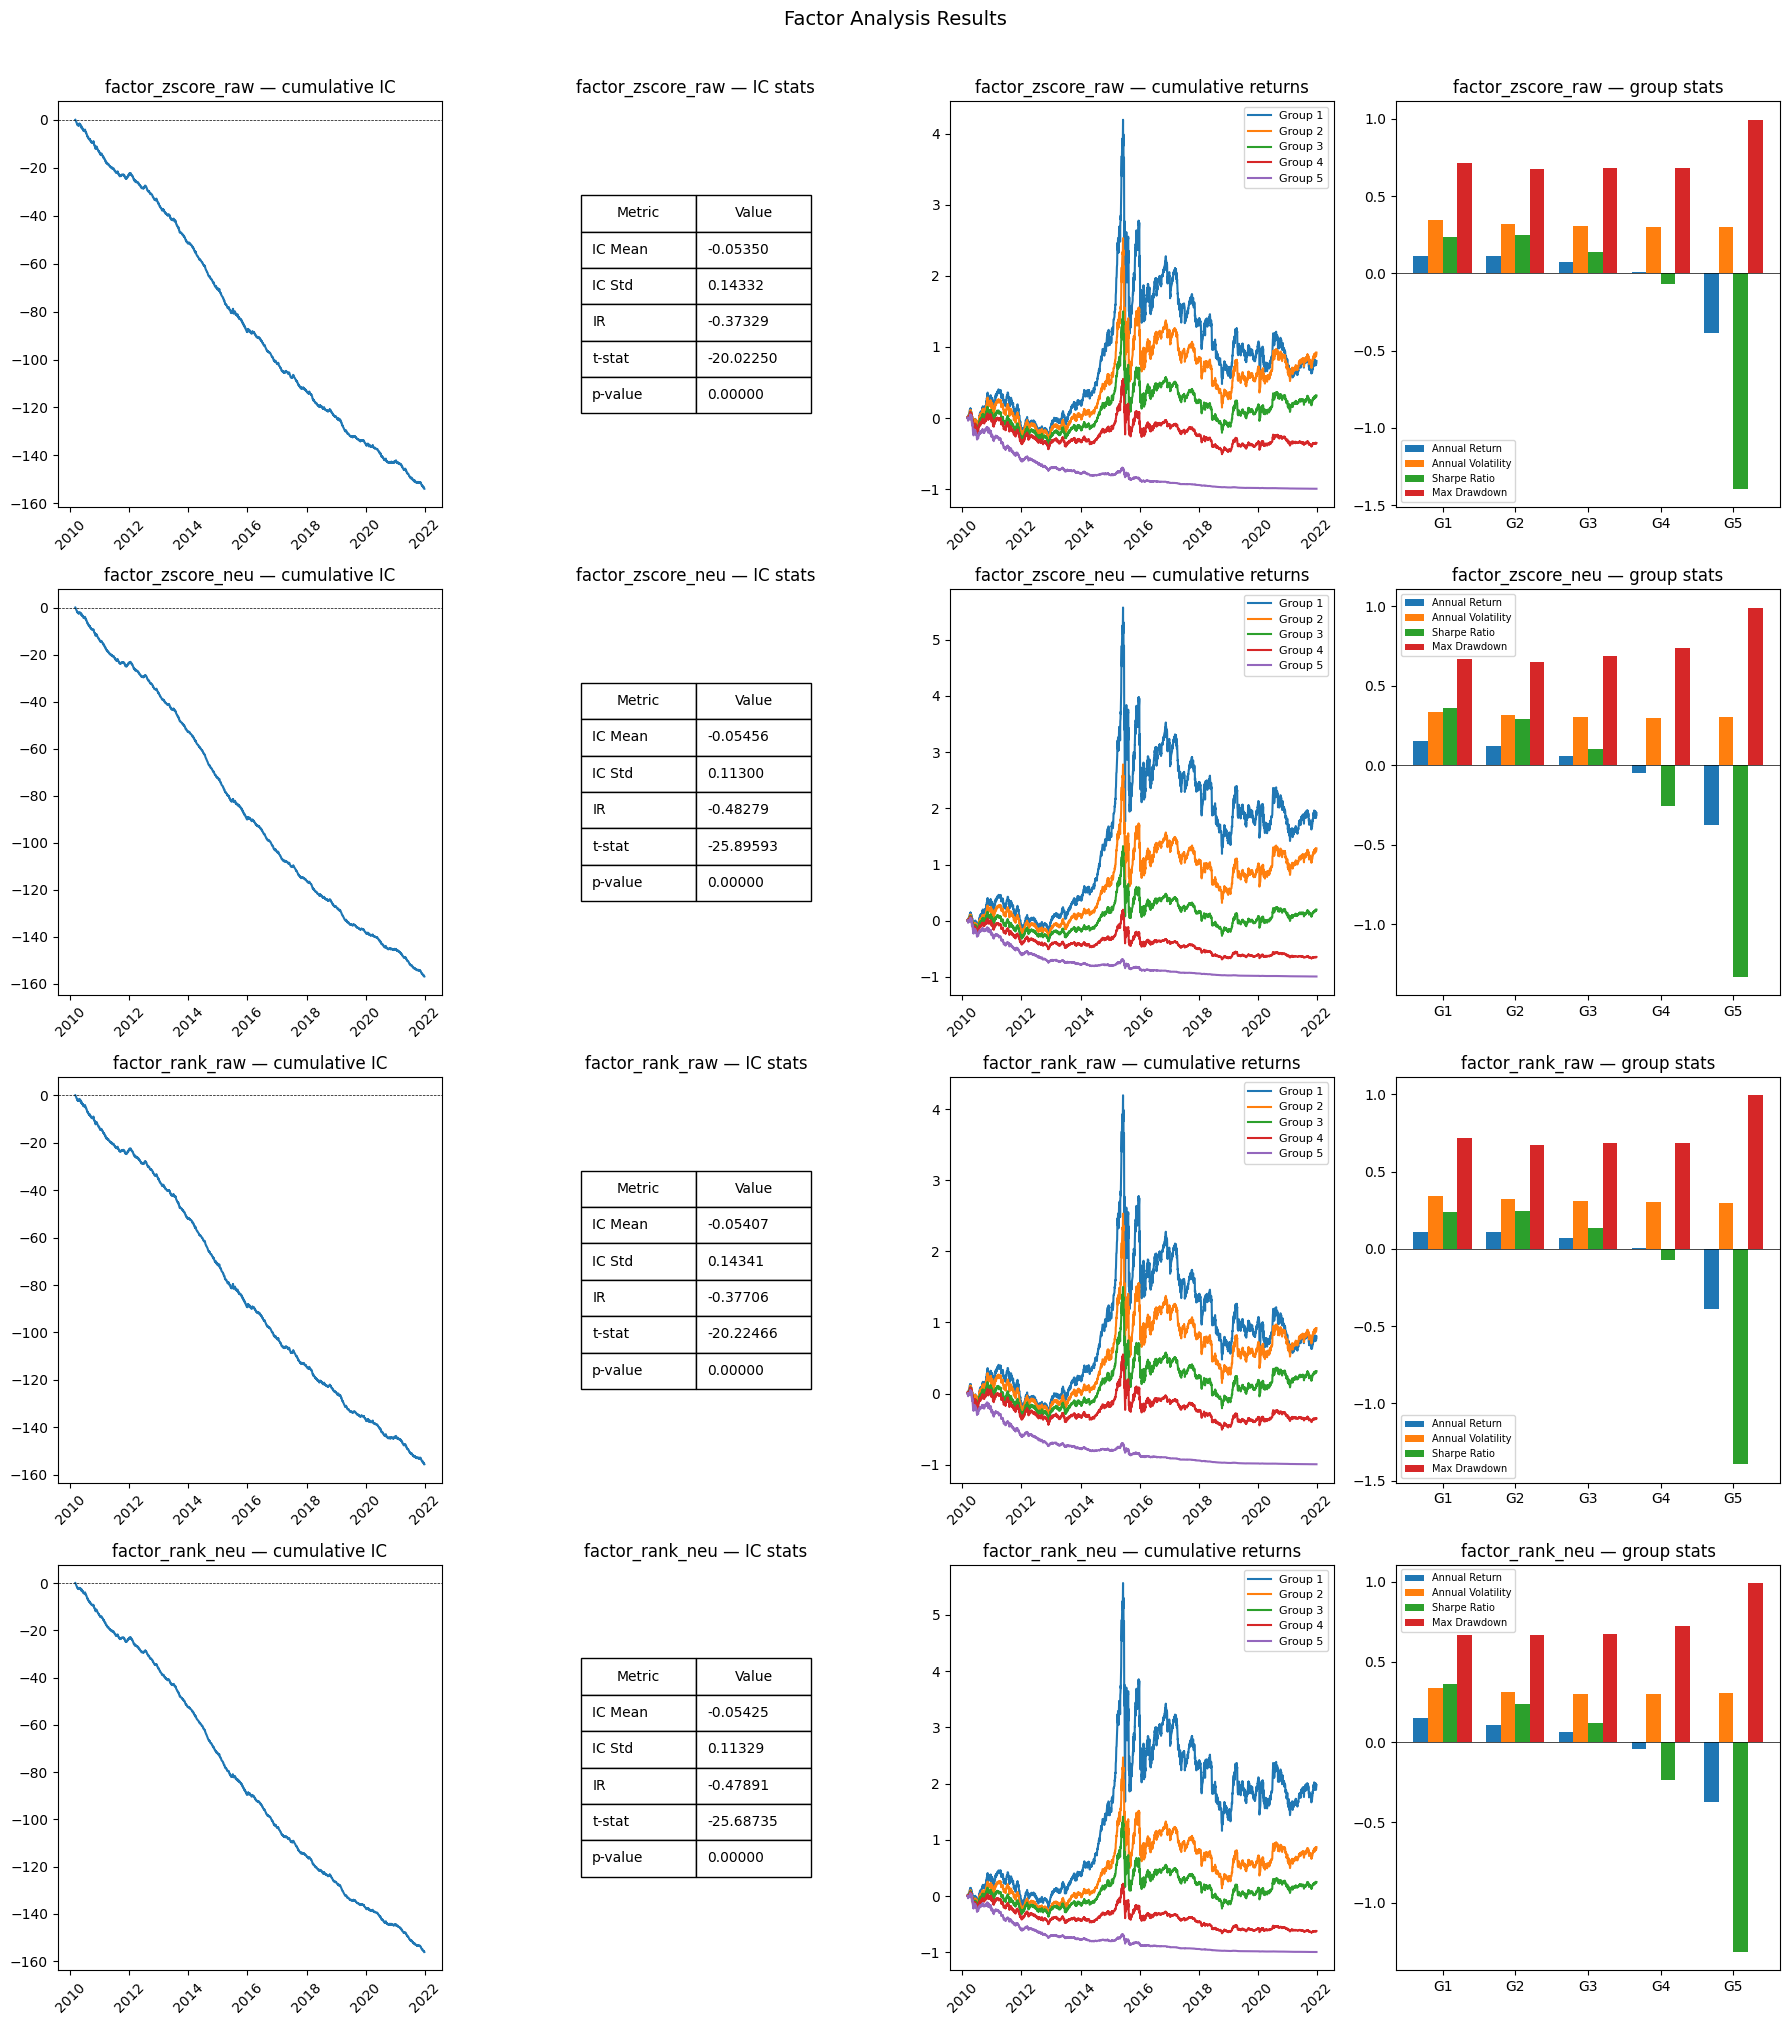

In [21]:
plot_results(ic_info, backtest_results)

In [22]:
portfolio = build_portfolio(df, industry_data, factor='factor_rank_neu', n=100, industry=['industry'], penalty=0.05, w_range=(0, 0.05), industry_range=(0, 0.05))

In [23]:
portfolio

weight
date       ticker              
2010-03-04 000547  3.765896e-09
           000735  3.142904e-09
           002105  1.456631e-09
           300012  3.766240e-09
           300021  3.142904e-09
...                         ...
2021-12-29 301080  1.000000e-02
           001213  1.000000e-02
           688606  1.000000e-02
           605365  1.000000e-02
           001216  1.000000e-02

[287700 rows x 1 columns]

In [24]:
portfolio_equity_curve, portfolio_metrics = backtest_portfolio(portfolio, df, risk_free_rate=0.03)

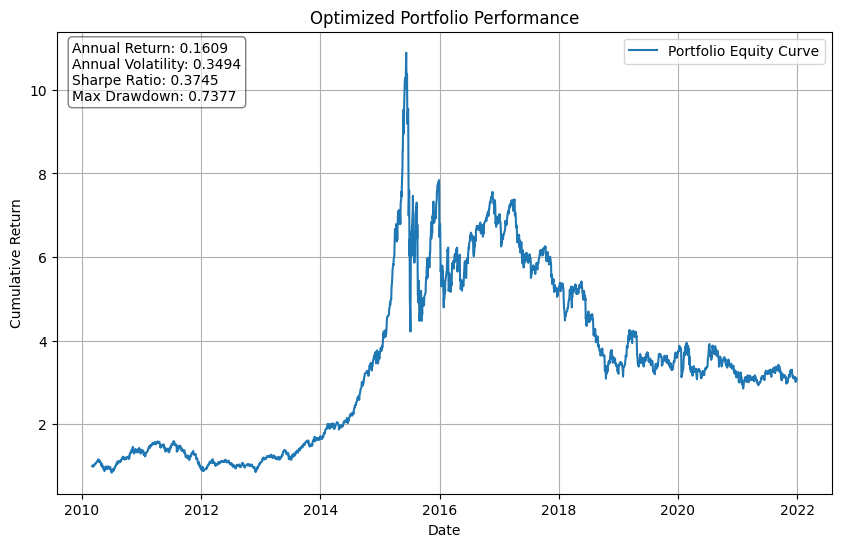

In [25]:
plot_portfolio_performance(portfolio_equity_curve, portfolio_metrics)